In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [10]:
df = pd.read_excel("data\premiums.xlsx")
df

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\shafi\AppData\Local\Temp\ipykernel_24124\3130933084.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_excel("data\premiums.xlsx")


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


In [11]:
df.shape

(50000, 13)

In [12]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [13]:
columns = df.columns
columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [14]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.columns


Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Handling missing values


In [15]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handling Duplicates


In [16]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Data Cleaning


In [17]:
df.number_of_dependants = df.number_of_dependants.abs()
df[df.number_of_dependants < 0].shape[0]

0

### Univariate Analysis: Numeric Columns
#### Box plots for numeric columns

In [18]:
numeric_cols = df.select_dtypes(['float64', 'int64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

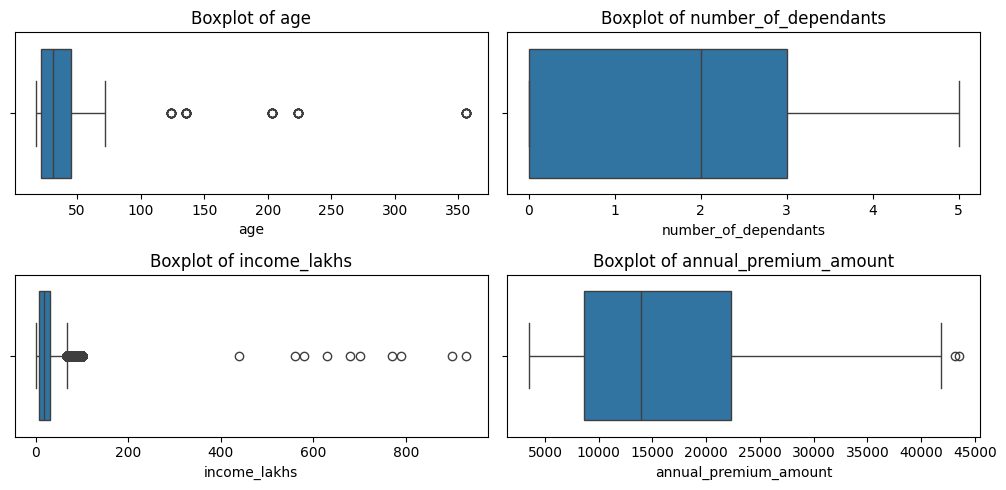

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < 4:
        sns.boxplot(x=df[col], ax=axes[idx])
        axes[idx].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


### Outlier Treatment 

In [20]:
df[df.age > 100].age.unique()

array([224, 124, 136, 203, 356])

In [21]:
# for age
df1 = df[df.age <= 100]
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


In [22]:
# for income
df1.income_lakhs.describe()

count    49918.000000
mean        23.025141
std         24.227912
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        930.000000
Name: income_lakhs, dtype: float64

In [23]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
df1[df1.income_lakhs > quantile_threshold].shape
#EDA part 1 ended

(10, 13)

In [24]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()

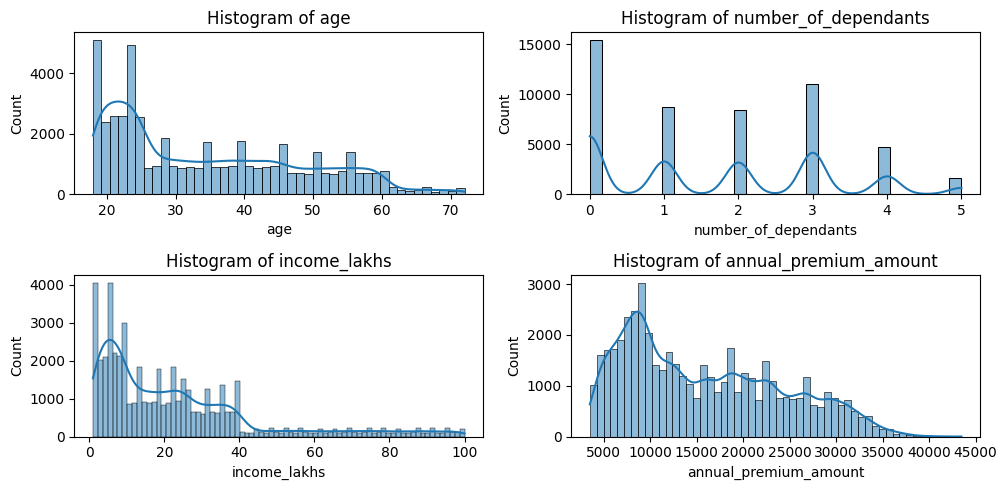

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

for idx, col in enumerate(numeric_cols):
    if idx < 4:
        sns.histplot(x=df2[col], ax=axes[idx//2, idx%2],kde=True)
        axes[idx//2, idx%2].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

### Bivariate Analysis : Numeric Columns


In [26]:
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

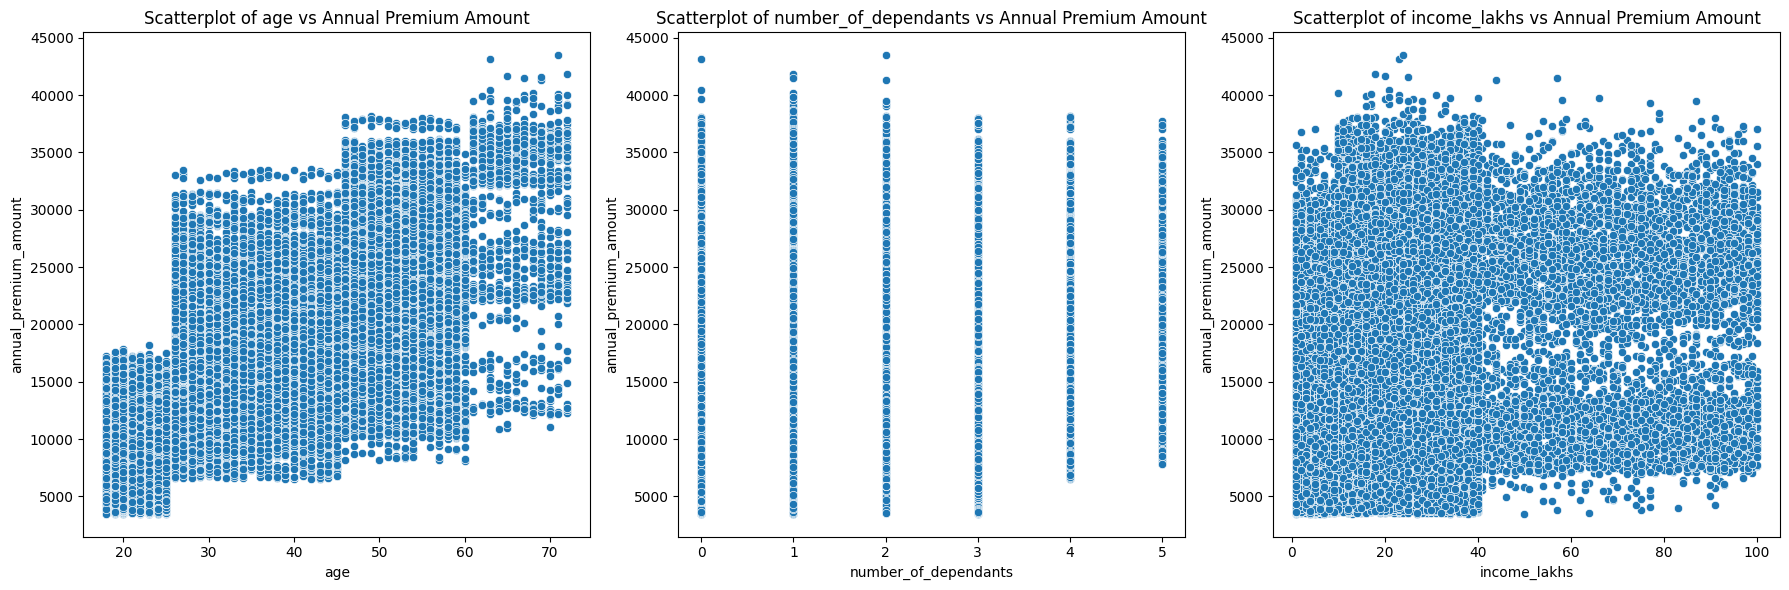

In [27]:
fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols[:-1]), figsize=(18, 6))
for col, ax in zip(numeric_cols[:-1], axes):
        sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=ax)
        ax.set_title(f'Scatterplot of {col} vs Annual Premium Amount')

plt.tight_layout()
plt.show()

### Categorical Columns



In [28]:
categorical_cols = df2.select_dtypes('object').columns
categorical_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [29]:
for col in categorical_cols:
    print(f'{col}: {df2[col].unique()}')


gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
income_level: ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [30]:
#fixing smoking status
df2.smoking_status = df2.smoking_status.replace(
    {
        'Not Smoking' : 'No Smoking',
        'Smoking=0' : 'No Smoking',
        'Does Not Smoke' : 'No Smoking',
    }
)
df2.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

### Univariate Analysis of Categorical Columns


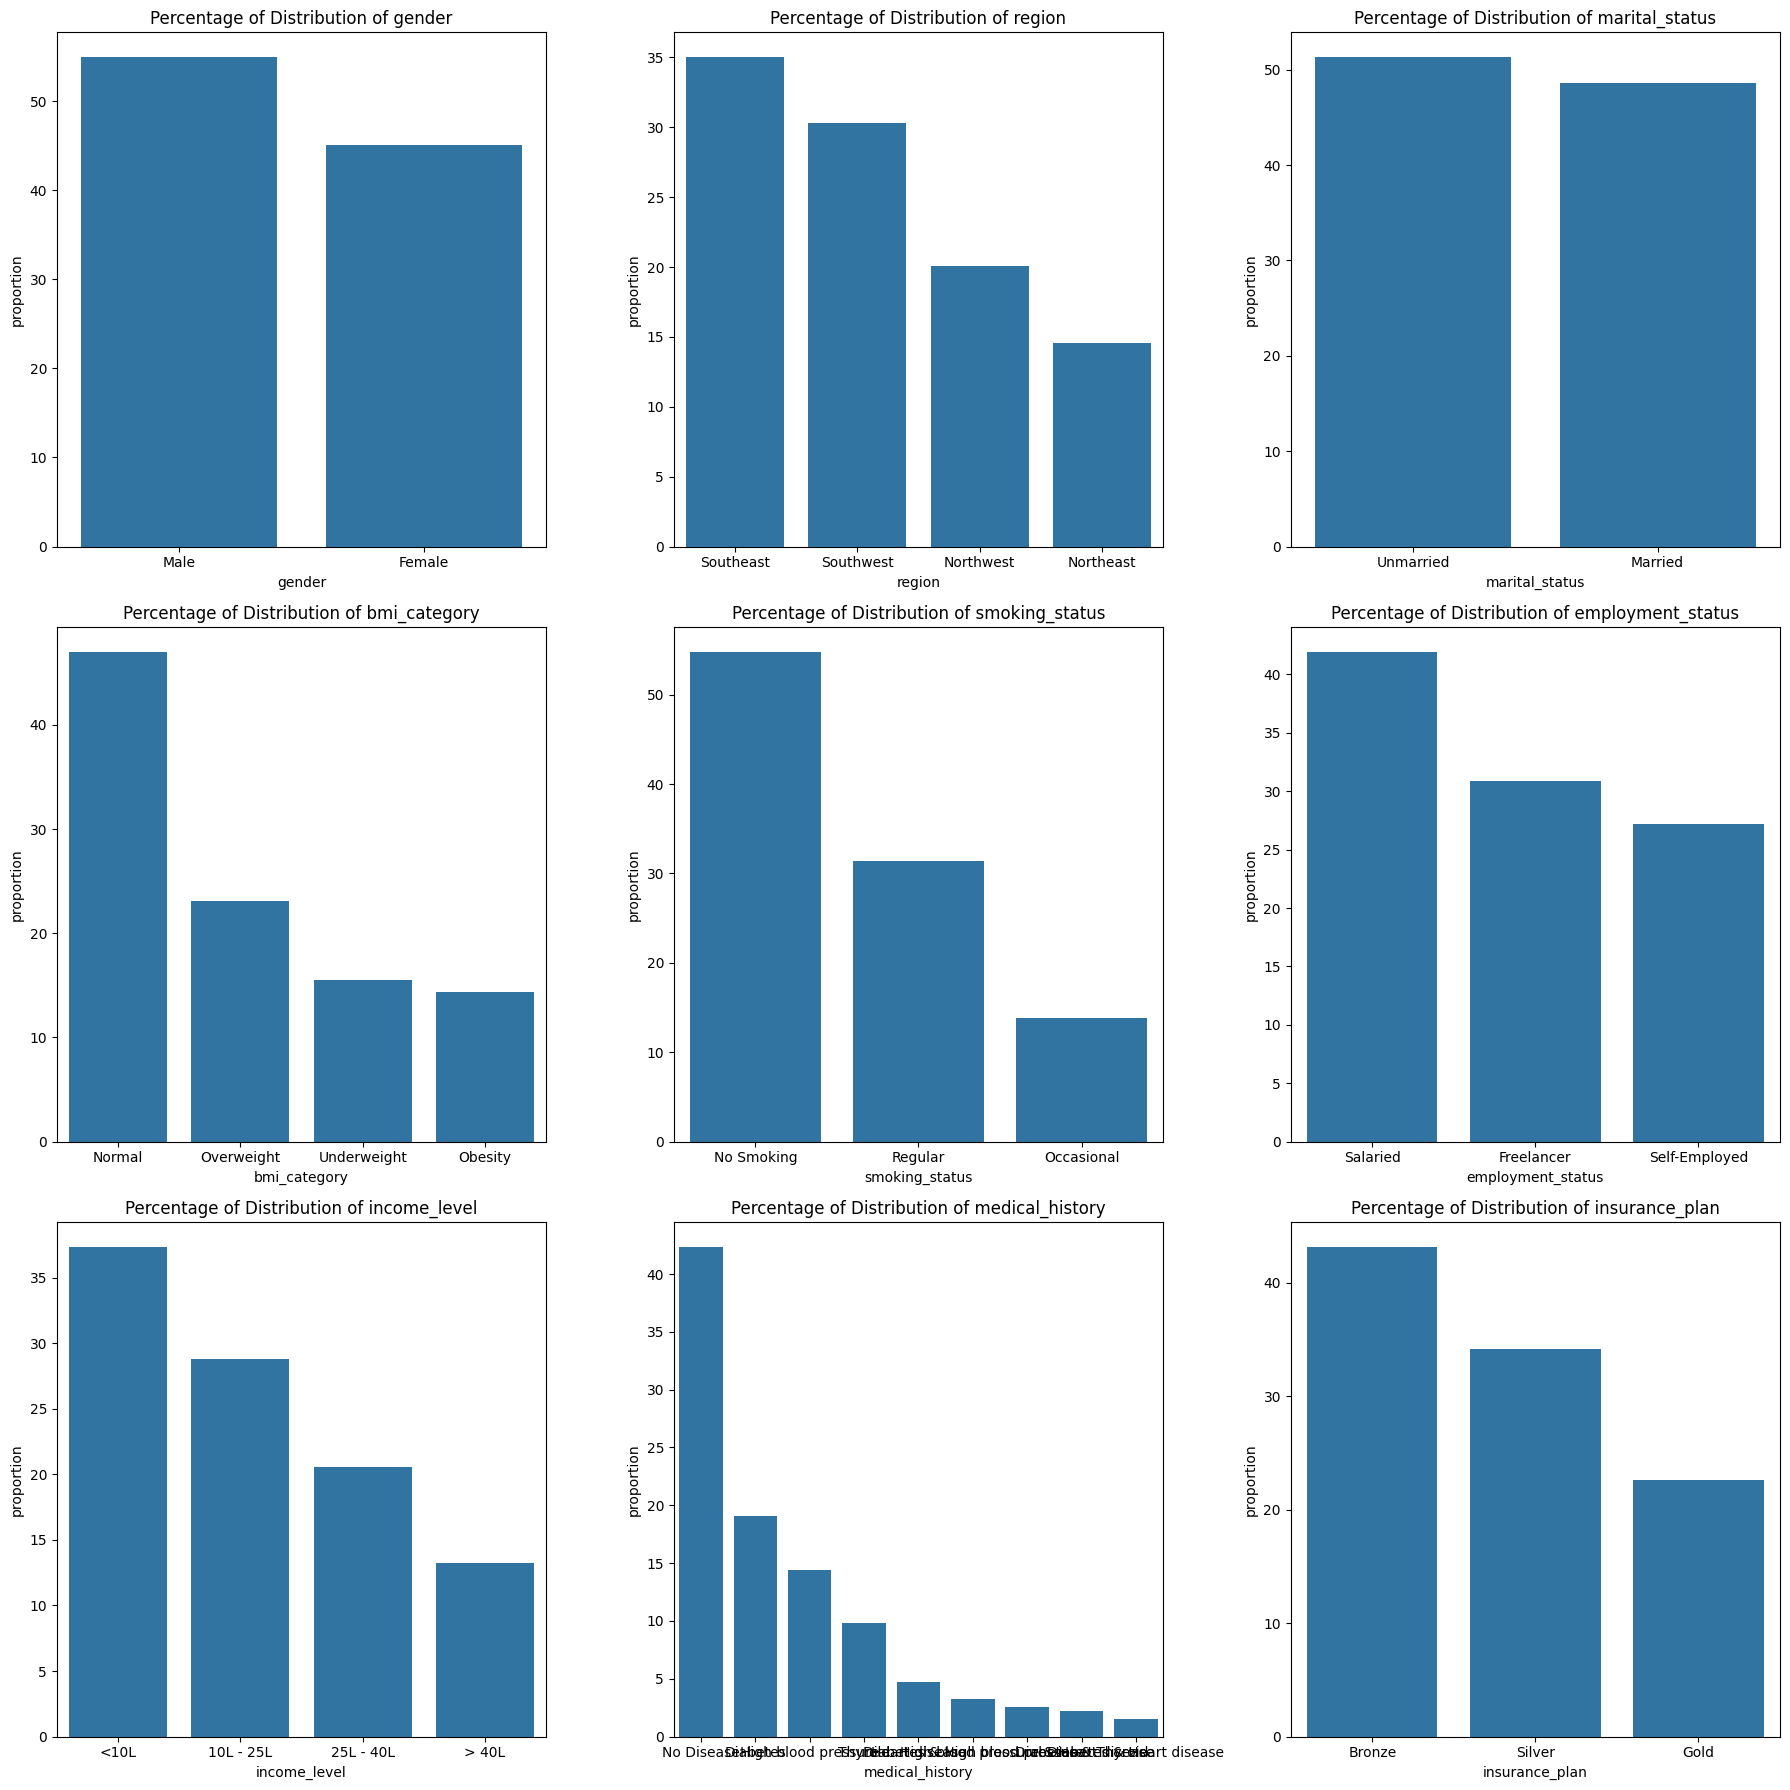

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for col,ax in zip(categorical_cols, axes.ravel()):
    # category_counts = df2[col].value_counts(normalize=True)*100
    sns.barplot(df2[col].value_counts(normalize=True)*100, ax=ax)
    ax.set_title(f'Percentage of Distribution of {col}')

plt.tight_layout()
plt.show()

### Bivariate Analysis of Categorical Columns


insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         5307  3880    5182
25L - 40L         3683  2840    3750
<10L             12226   931    5486
> 40L              329  3653    2641


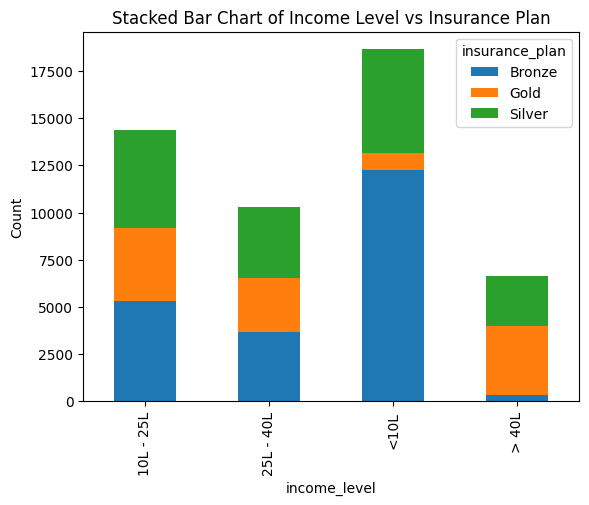

In [32]:
crosstab = pd.crosstab(df2['income_level'],df2['insurance_plan'])
print(crosstab)
crosstab.plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Income Level vs Insurance Plan')    
plt.ylabel('Count')
plt.show()

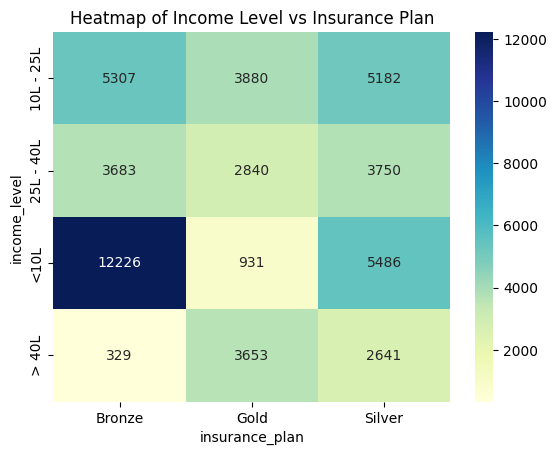

In [33]:
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Income Level vs Insurance Plan')
plt.show()
### EDA part 2 ended

## Feature Engineering

In [34]:

df2['medical_history'] = df2['medical_history'].str.lower()
df2['medical_history'].unique()

array(['diabetes', 'high blood pressure', 'no disease',
       'diabetes & high blood pressure', 'thyroid', 'heart disease',
       'high blood pressure & heart disease', 'diabetes & thyroid',
       'diabetes & heart disease'], dtype=object)

In [35]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [36]:
# Create risk score mapping for ALL possible medical history combinations
risk_score_mapping = {
    # Single diseases
    'diabetes': 6,
    'high blood pressure': 6,
    'thyroid': 5,
    'heart disease': 8,
    'no disease': 0,
    # 2-disease combinations
    'diabetes & high blood pressure': 12,
    'diabetes & thyroid': 11,
    'diabetes & heart disease': 14,
    'high blood pressure & thyroid': 11,
    'high blood pressure & heart disease': 14,
    'thyroid & heart disease': 13,
    # 3-disease combinations
    'diabetes & high blood pressure & thyroid': 17,
    'diabetes & high blood pressure & heart disease': 20,
    'diabetes & thyroid & heart disease': 19,
    'high blood pressure & thyroid & heart disease': 19,
    # 4-disease combination
    'diabetes & high blood pressure & thyroid & heart disease': 25
}

from sklearn.preprocessing import minmax_scale
# Map medical_history to risk_score
df2['risk_score'] = df2['medical_history'].map(risk_score_mapping)
df2['normalized_risk_score'] = minmax_scale(df2['risk_score'])
df2[['medical_history', 'risk_score', 'normalized_risk_score']].sample(10)

,medical_history,risk_score,normalized_risk_score
862,no disease,0,0.000000
48251,diabetes,6,0.428571
17273,high blood pressure & heart disease,14,1.000000
10223,no disease,0,0.000000
37345,high blood pressure,6,0.428571
49994,diabetes,6,0.428571
28893,diabetes,6,0.428571
9721,diabetes,6,0.428571
47403,no disease,0,0.000000
38206,diabetes,6,0.428571


In [37]:
## ordinal columns label encoding (insurance plan and income level)
# insurance plan label encoding 
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.insurance_plan.unique()

array([1, 2, 3])

In [38]:
# income level label encoding
df2.income_level.unique()
df2['income_level'] = df2['income_level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})
df2.income_level.unique()

array([1, 2, 4, 3])

In [39]:
# nominal columns one hot encoding
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status','employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head()
df4 = pd.get_dummies(df2, columns=nominal_cols, drop_first=False, dtype=int) # to check multicolinearity in VIF
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,risk_score,normalized_risk_score,gender_Male,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,diabetes,1,9053,6,0.428571,1,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,diabetes,1,16339,6,0.428571,0,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,high blood pressure,2,18164,6,0.428571,0,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,no disease,3,20303,0,0.000000,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,high blood pressure,2,13365,6,0.428571,1,...,0,0,1,0,1,0,0,1,0,1


In [40]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49908 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              49908 non-null  int64  
 1   number_of_dependants             49908 non-null  int64  
 2   income_level                     49908 non-null  int64  
 3   income_lakhs                     49908 non-null  int64  
 4   medical_history                  49908 non-null  object 
 5   insurance_plan                   49908 non-null  int64  
 6   annual_premium_amount            49908 non-null  int64  
 7   risk_score                       49908 non-null  int64  
 8   normalized_risk_score            49908 non-null  float64
 9   gender_Male                      49908 non-null  int64  
 10  region_Northwest                 49908 non-null  int64  
 11  region_Southeast                 49908 non-null  int64  
 12  region_Southwest       

### Feature Selection

In [41]:
df5 = df3.drop(columns = ['medical_history','risk_score'])
df5.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


### Calculate VIF for Multicolinearity

In [42]:
df5.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

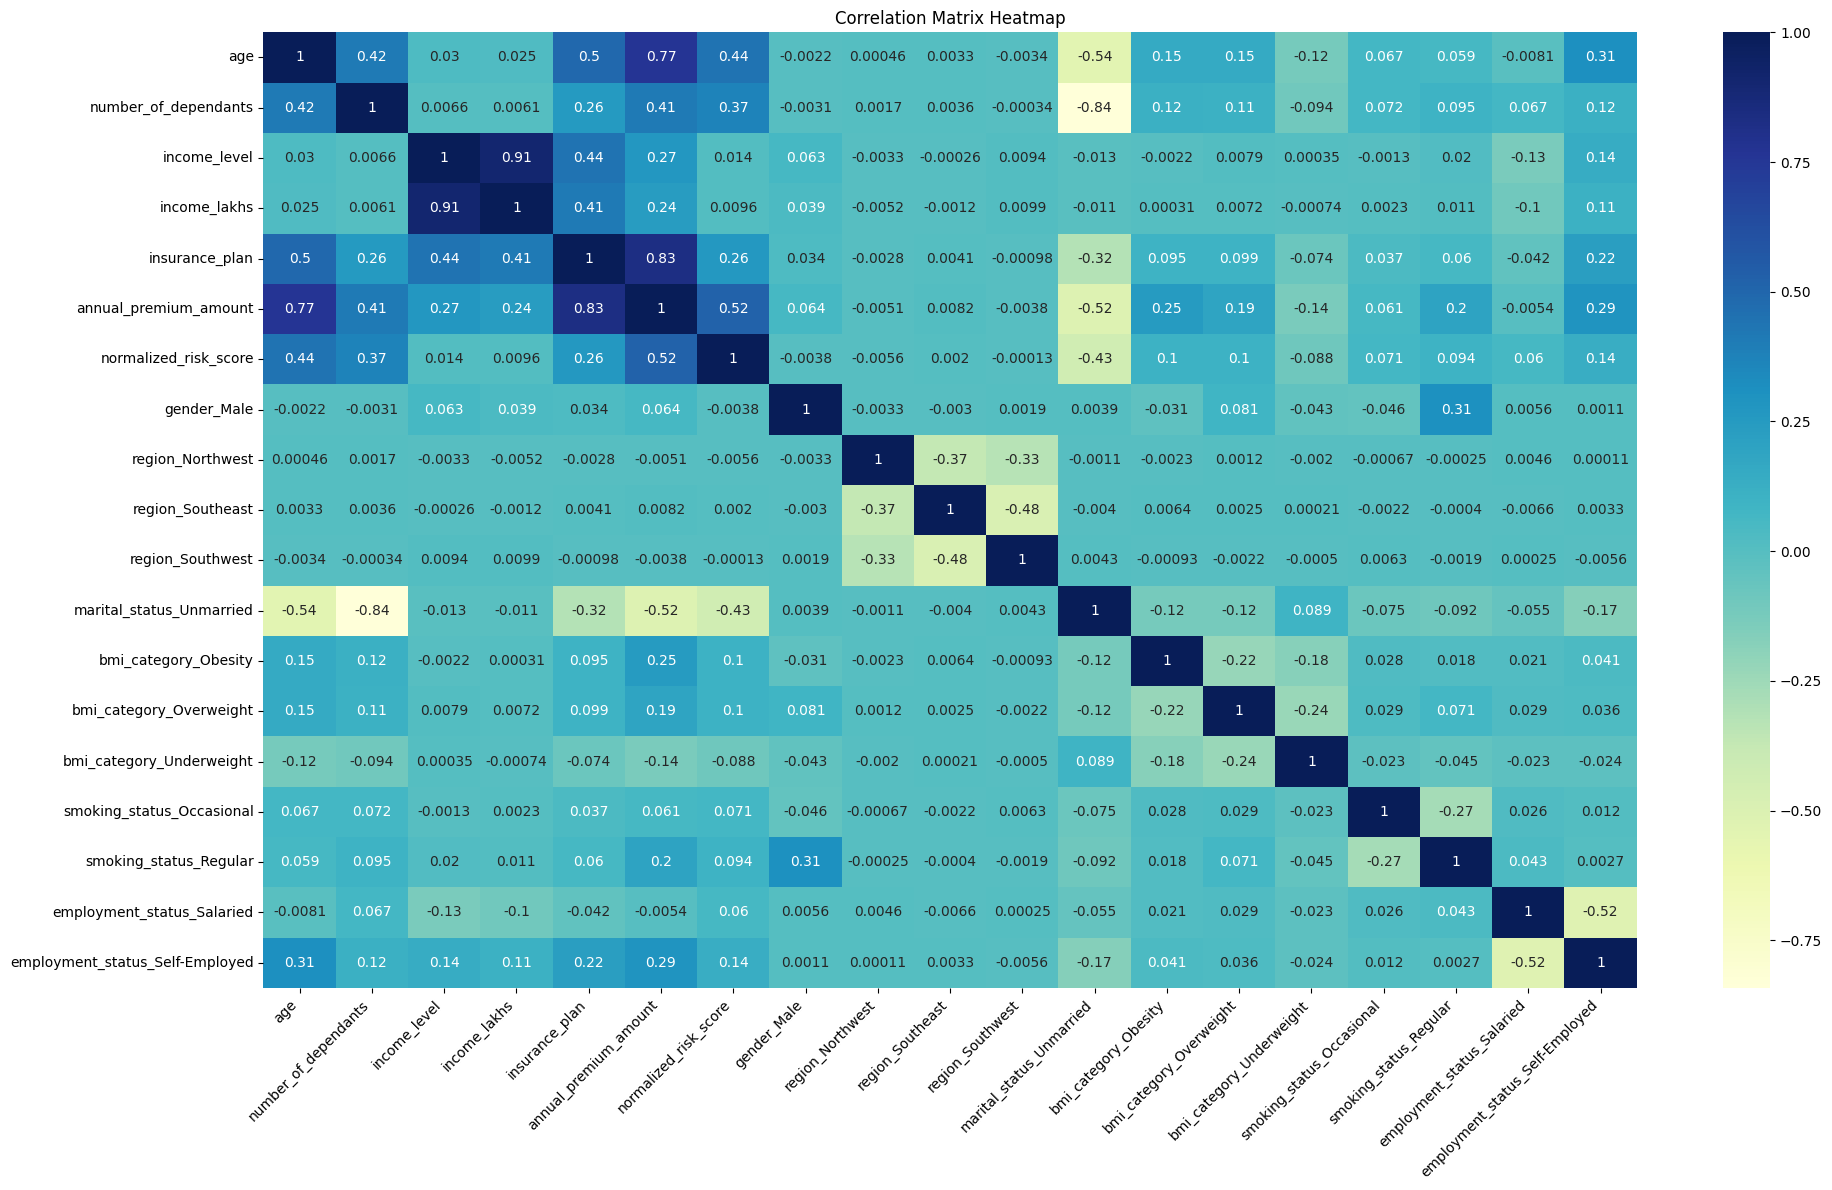

In [43]:
cm = df5.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [44]:
X = df5.drop(columns=['annual_premium_amount'])
y = df5['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
X[cols_to_scale] = scalar.fit_transform(X[cols_to_scale])
X.describe()


,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df['feature'] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df

In [46]:
calculate_vif(X)

,feature,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [47]:
calculate_vif(X.drop(columns=['income_level'])) #dont need axis = 1 if columns = used

,feature,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


In [48]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop(columns=['income_level'])

In [49]:
### for experiment with VIF & multicolinearity
df4.drop(columns = ['medical_history'], inplace=True)
X_t = df4.drop(columns=['annual_premium_amount'])
cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
X_t[cols_to_scale] = minmax_scale(X_t[cols_to_scale])
y = df4['annual_premium_amount']    
calculate_vif(X_t)

c:\Users\shafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,age,2.034245
1,number_of_dependants,3.488890
2,income_level,5.961607
3,income_lakhs,5.665263
4,insurance_plan,1.770156
5,risk_score,inf
6,normalized_risk_score,inf
7,gender_Female,inf
8,gender_Male,inf
9,region_Northeast,inf


## Model Training


In [50]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)

print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Test set shape: {X_test.shape}, {y_test.shape}')

Training set shape: (34935, 17), (34935,)
Test set shape: (14973, 17), (14973,)


In [52]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
train_score = model_lr.score(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score, test_score


(0.9282143576916762, 0.9280547230217837)

In [53]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  5165611.913027983 RMSE:  2272.798256121291


In [54]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([11160.926462,  -676.443991,  -514.229816, 12557.012936,
        4810.357702,   168.646662,   -35.719292,    39.96513 ,
         -24.652929,  -935.760611,  3387.911455,  1599.362268,
         391.171304,   735.912278,  2234.804712,   155.984674,
         415.903973])

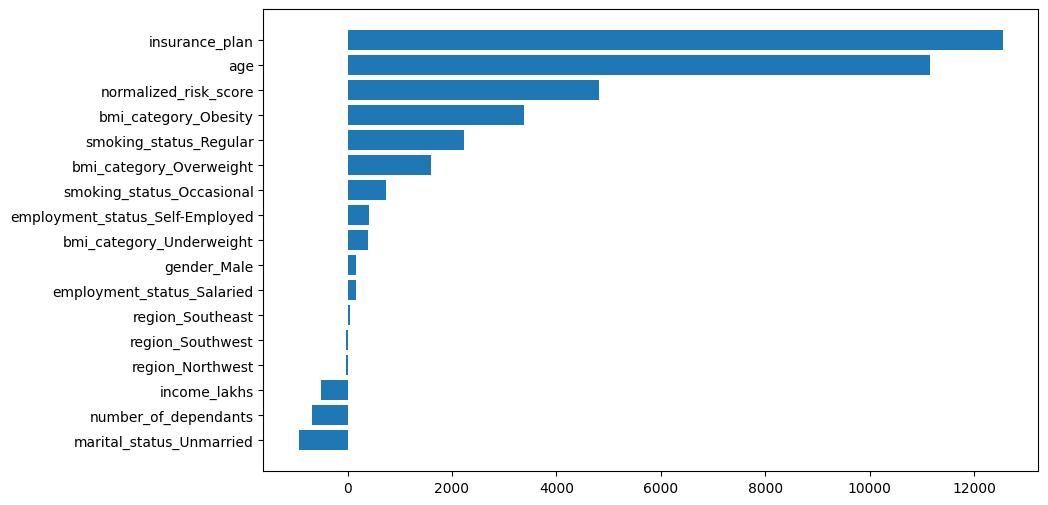

In [55]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance,index= X_train.columns, columns=['Coefficient'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(coef_df.index, coef_df['Coefficient'])
plt.show()

### Ridge Regression



In [56]:

model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)
train_score_rg = model_rg.score(X_train, y_train)
test_score_rg = model_rg.score(X_test, y_test)
train_score_rg, test_score_rg

(0.9282143198366275, 0.9280541644640345)

In [57]:
y_pred = model_rg.predict(X_test)
mse_rg = mean_squared_error(y_test, y_pred)
rmse_rg = np.sqrt(mse_rg)
print("Ridge Regression ==> MSE: ", mse_rg, "RMSE: ", rmse_rg)

Ridge Regression ==> MSE:  5165652.017016523 RMSE:  2272.8070787060924


### XG Boost

In [58]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
train_score_xgb = model_xgb.score(X_train, y_train)
test_score_xgb = model_xgb.score(X_test, y_test)
train_score_xgb, test_score_xgb

(0.9860964417457581, 0.9809534549713135)

In [59]:
y_pred = model_xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
print("XGBoost Regression ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGBoost Regression ==> MSE:  1367525.625 RMSE:  1169.4125127601467


In [60]:
model_xgb =  XGBRegressor()
param_grid = {
    'n_estimators':[20, 40, 50],
     'learning_rate':[0.01, 0.1, 0.2],
     'max_depth':[3, 4, 5]
}
random_search = RandomizedSearchCV(model_xgb, param_grid, cv=3, n_iter=10, random_state=42, scoring='r2', n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9809474547704061)

In [61]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [62]:
best_model = random_search.best_estimator_
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

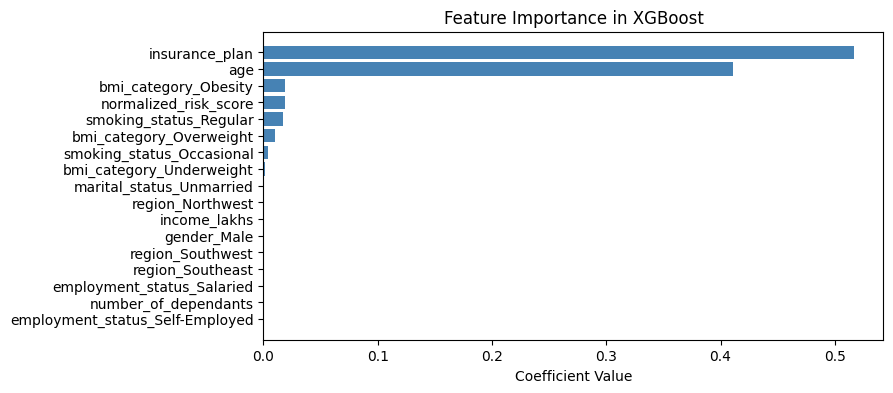

In [63]:
feature_importance = best_model.feature_importances_

coef_df = pd.DataFrame(feature_importance,index= X_train.columns, columns=['Coefficient'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

## Error Analysis

In [64]:
# 98% r2 score with XGBoost doesnt mean its deploayable
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'residuals': residuals,
    'residuals_pct': residuals_pct
})

results_df

,actual,predicted,residuals,residuals_pct
3598,20554,20334.953125,-219.046875,-1.065714
35794,29647,29378.779297,-268.220703,-0.904714
43608,20560,20618.185547,58.185547,0.283004
42730,5018,7352.829590,2334.829590,46.529087
18936,8929,8203.291992,-725.708008,-8.127540
...,...,...,...,...
5621,18848,18649.619141,-198.380859,-1.052530
6069,6956,6565.852051,-390.147949,-5.608797
21592,8332,10615.658203,2283.658203,27.408284
49274,5571,6820.886230,1249.886230,22.435581


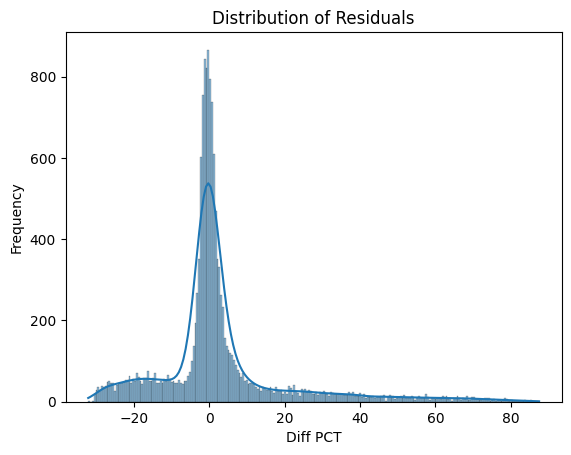

In [65]:
sns.histplot(results_df['residuals_pct'],kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [66]:
extreme_error_threshold = 10
extreme_results_df = results_df[results_df['residuals_pct'].abs() > extreme_error_threshold]
extreme_results_df


,actual,predicted,residuals,residuals_pct
42730,5018,7352.829590,2334.829590,46.529087
20029,5140,6670.849121,1530.849121,29.783057
4294,9631,7053.477539,-2577.522461,-26.762771
44419,4687,6670.849121,1983.849121,42.326629
6707,8826,10047.326172,1221.326172,13.837822
...,...,...,...,...
8767,8113,6565.852051,-1547.147949,-19.069986
25179,9944,7058.687988,-2885.312012,-29.015608
21592,8332,10615.658203,2283.658203,27.408284
49274,5571,6820.886230,1249.886230,22.435581


In [67]:
extreme_results_df.shape

(4487, 4)

In [68]:
extreme_error_pct = (extreme_results_df.shape[0] / results_df.shape[0]) * 100
extreme_error_pct
#30% of the errrors are extreme, for this case more than 10%. 30% of the customers we will either over/under charge by 10%


29.967274427302478

In [69]:
extreme_df = X_test.loc[extreme_results_df.index]
extreme_df

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.428571,1,0,0,0,1,0,1,0,0,0,0,0
20029,0.018519,0.2,0.030303,0.0,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.000000,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.000000,0,0,0,0,1,0,0,1,0,0,0,0
6707,0.111111,0.2,0.070707,0.5,0.000000,1,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8767,0.018519,0.2,0.070707,0.0,0.000000,0,0,1,0,1,0,0,0,0,0,0,0
25179,0.129630,0.0,0.111111,0.0,0.000000,1,0,0,0,1,0,0,0,0,1,0,0
21592,0.055556,0.0,0.060606,0.5,0.000000,1,0,0,0,1,0,0,0,0,1,0,0
49274,0.055556,0.2,0.070707,0.0,0.000000,0,0,0,0,1,0,0,0,1,0,0,0


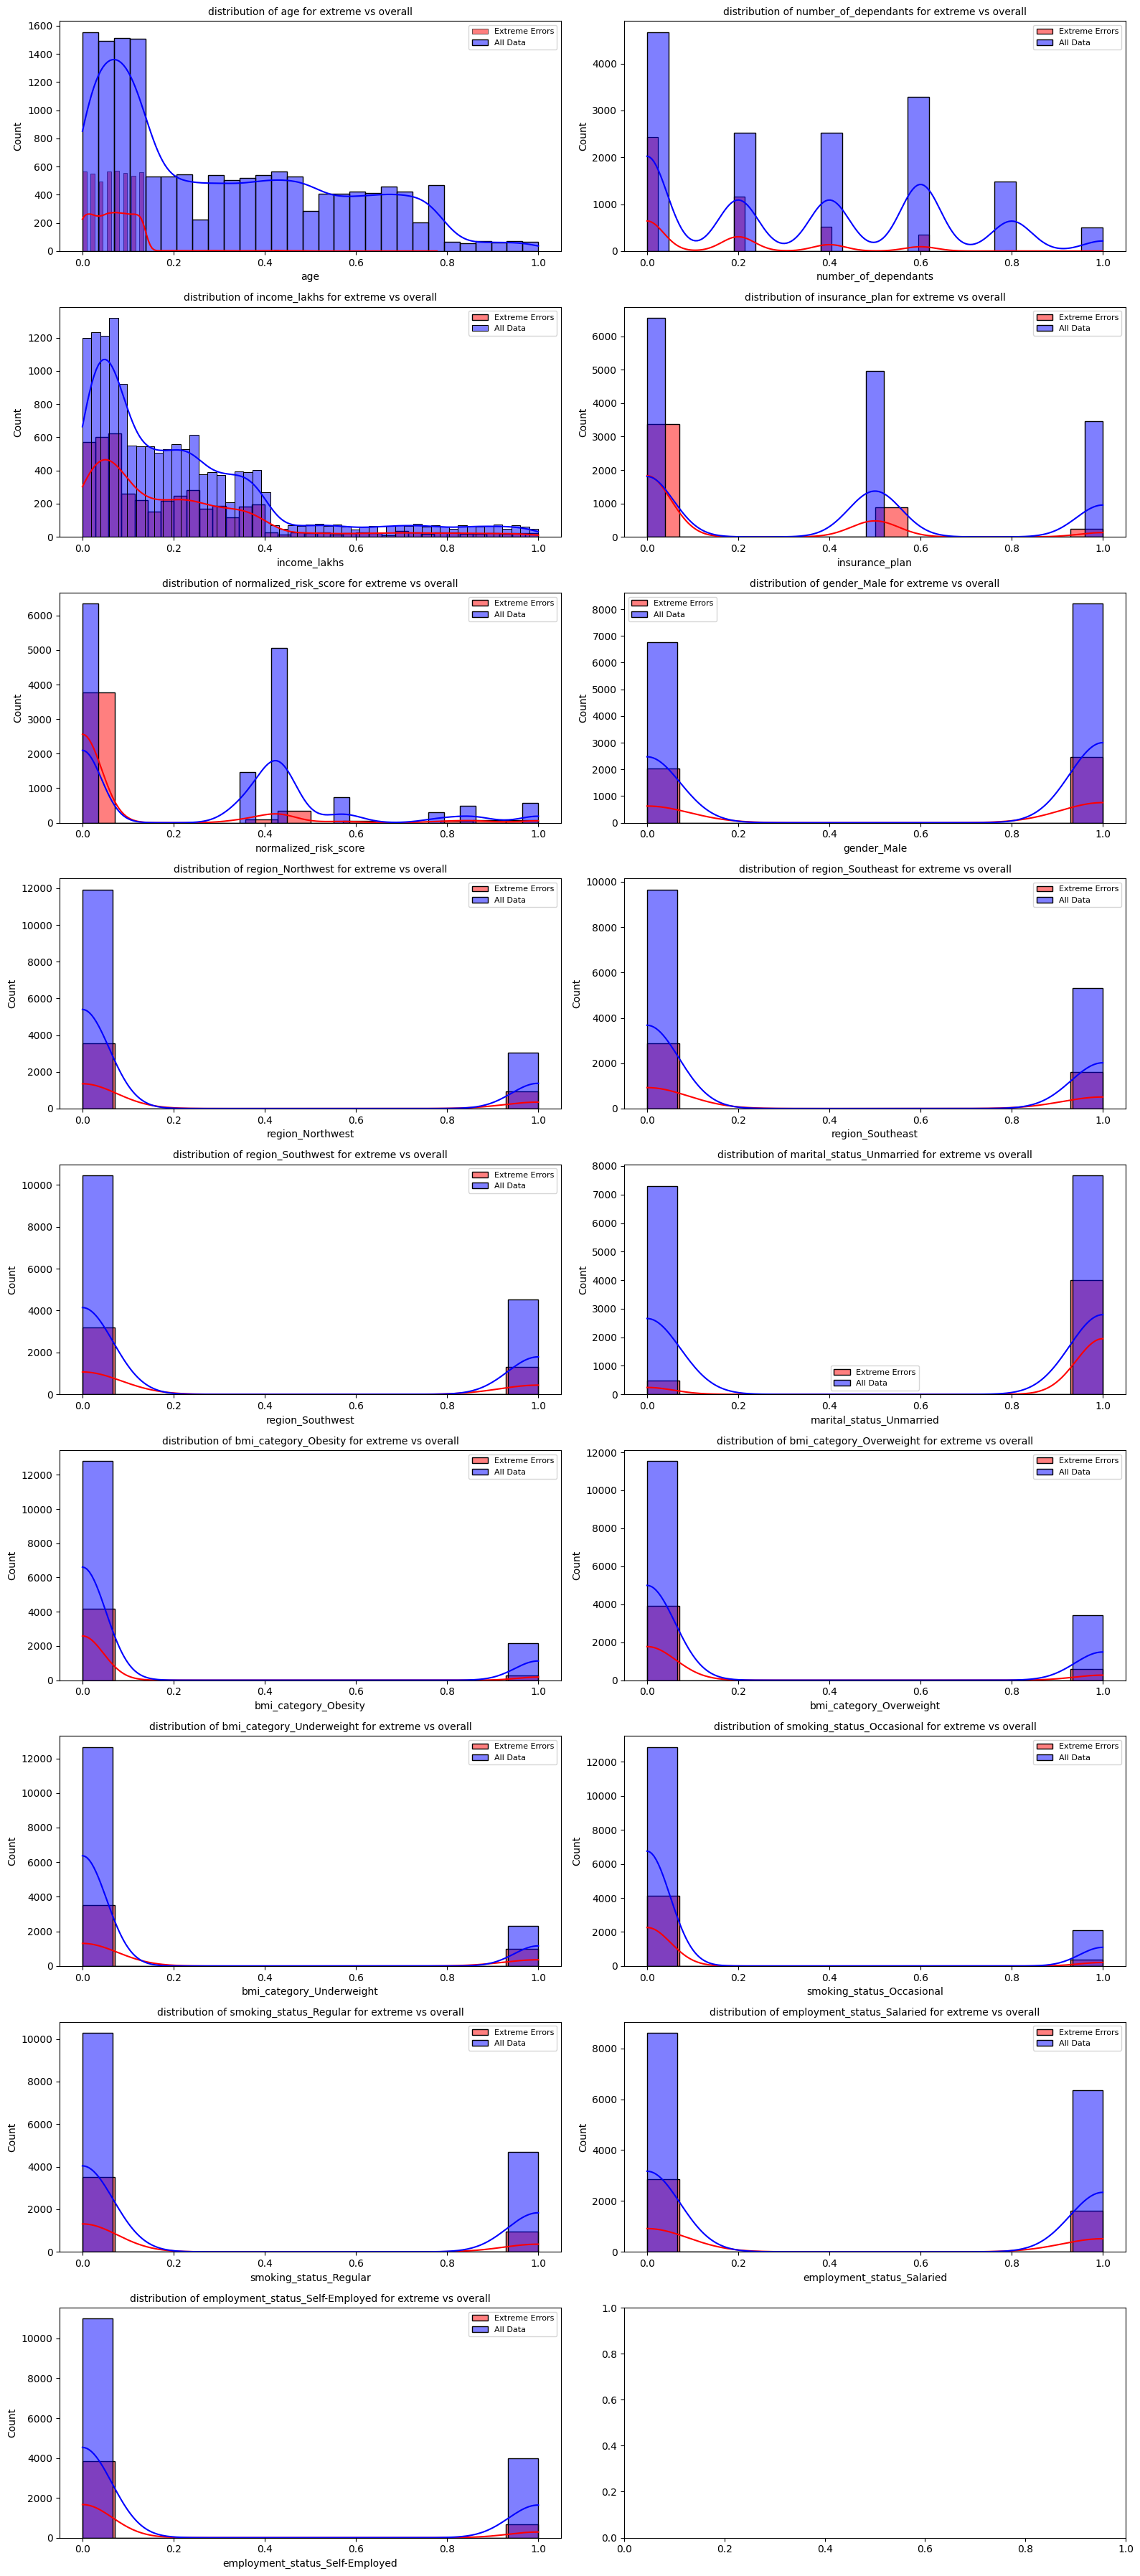

In [70]:
fig, axes = plt.subplots(9,2, figsize=(16, 36))
for col, ax in zip(extreme_df.columns, axes.ravel()):
    sns.histplot(x=extreme_df[col], ax=ax, kde=True, color ='red', label = 'Extreme Errors')
    sns.histplot(x=X_test[col], ax=ax, kde=True, color='blue', alpha=0.5, label='All Data')
    ax.set_title(f'distribution of {col} for extreme vs overall', fontsize=10)
    ax.legend(fontsize= 8)

plt.tight_layout()
plt.show()

### Reverse Scaling


In [71]:
df_reversed = pd.DataFrame()
extreme_df['income_level'] = -1 # since this column was dropped in VIF, we will assign -1 to it to avoid error in inverse transform
df_reversed[cols_to_scale] = scalar.inverse_transform(extreme_df[cols_to_scale])
df_reversed

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,23.0,1.0,-2.0,14.0,1.0
1,19.0,1.0,-2.0,4.0,1.0
2,18.0,1.0,-2.0,3.0,1.0
3,21.0,0.0,-2.0,25.0,1.0
4,24.0,1.0,-2.0,8.0,2.0
...,...,...,...,...,...
4482,19.0,1.0,-2.0,8.0,1.0
4483,25.0,0.0,-2.0,12.0,1.0
4484,21.0,0.0,-2.0,7.0,2.0
4485,21.0,1.0,-2.0,8.0,1.0


In [72]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4487.000000,4487.000000,4487.0,4487.000000,4487.000000
mean,21.804992,0.739247,-2.0,21.182527,1.302429
std,3.172355,0.968855,0.0,20.598596,0.563135
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,24.000000,1.000000,-2.0,30.000000,1.000000
max,60.000000,5.000000,-2.0,100.000000,3.000000


<Axes: xlabel='age', ylabel='Count'>

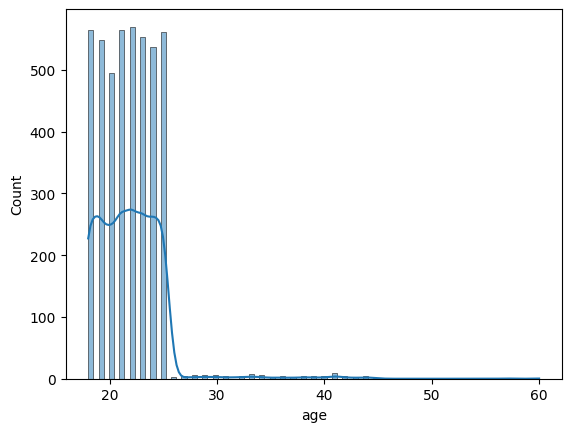

In [73]:
sns.histplot(df_reversed['age'], kde=True)

#### This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment


## Model Segmentation

In [74]:
#separating premiums.xlsx into young and rest & building model specific to young age group (age<25)
df_young = df[df['Age']<=25]
df_rest = df[df['Age']>25]
df_young.shape, df_rest.shape

KeyError: 'Age'

In [ ]:
df_young.to_excel("premiums_young.xlsx", index=False)
df_rest.to_excel("premiums_rest.xlsx", index=False)